In [1]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [3]:
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)

<Axes: >

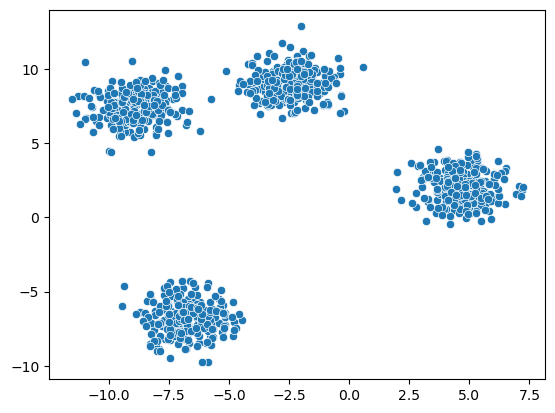

In [5]:
# Visualization

sns.scatterplot(x=X[: ,0] , y =X[: , 1])

In [6]:
from sklearn.cluster import KMeans

In [8]:
K = 4

kmeans = KMeans(
    n_clusters=K,
    random_state=42
)

In [9]:
labels = kmeans.fit_predict(X)


In [10]:
labels

array([3, 1, 1, 2, 2, 1, 2, 1, 1, 2, 2, 3, 0, 1, 1, 1, 0, 0, 0, 2, 2, 3,
       3, 3, 2, 2, 0, 0, 1, 2, 1, 1, 1, 0, 0, 3, 1, 2, 3, 3, 2, 1, 2, 3,
       2, 3, 0, 2, 3, 2, 1, 0, 2, 3, 0, 3, 0, 0, 0, 1, 1, 0, 1, 3, 2, 0,
       1, 1, 2, 0, 3, 0, 2, 1, 2, 3, 2, 0, 2, 0, 1, 0, 0, 0, 2, 3, 1, 1,
       0, 0, 0, 0, 2, 2, 3, 2, 3, 0, 2, 1, 2, 3, 3, 0, 3, 2, 2, 0, 1, 0,
       3, 1, 2, 2, 2, 2, 1, 3, 1, 2, 0, 1, 3, 2, 3, 1, 2, 3, 1, 2, 0, 1,
       2, 3, 2, 3, 0, 1, 2, 2, 0, 0, 3, 3, 3, 2, 2, 0, 0, 0, 0, 3, 1, 1,
       0, 2, 0, 2, 2, 3, 1, 0, 2, 1, 0, 0, 2, 1, 3, 1, 2, 0, 0, 2, 0, 3,
       1, 3, 1, 3, 2, 2, 0, 1, 0, 1, 2, 3, 0, 1, 2, 0, 2, 2, 0, 3, 1, 1,
       1, 3, 0, 1, 2, 0, 2, 2, 1, 0, 2, 1, 1, 3, 1, 1, 2, 0, 1, 0, 3, 2,
       3, 3, 1, 0, 3, 0, 2, 1, 1, 0, 0, 1, 0, 3, 1, 1, 3, 1, 1, 2, 1, 3,
       1, 2, 3, 0, 2, 0, 2, 2, 2, 2, 3, 2, 2, 1, 0, 1, 1, 2, 2, 2, 3, 2,
       3, 3, 1, 2, 0, 3, 2, 0, 2, 1, 0, 3, 2, 3, 1, 2, 3, 1, 3, 2, 1, 0,
       0, 1, 0, 3, 3, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,

<Axes: >

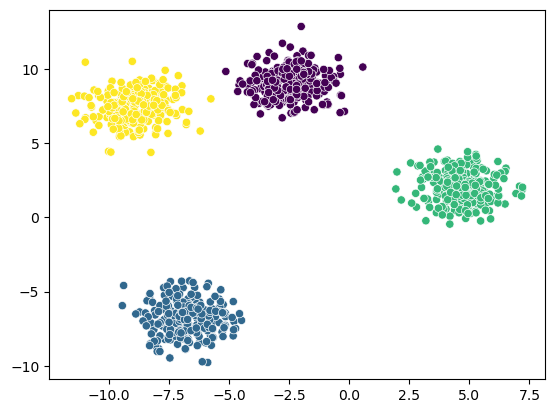

In [11]:
sns.scatterplot(x =X[: ,0] , y= X[: ,1] , c =labels)

In [13]:
# Elbow Method 

wcss = []

for K in range(1,21):
    kmeans = KMeans(n_clusters =K)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

<Axes: >

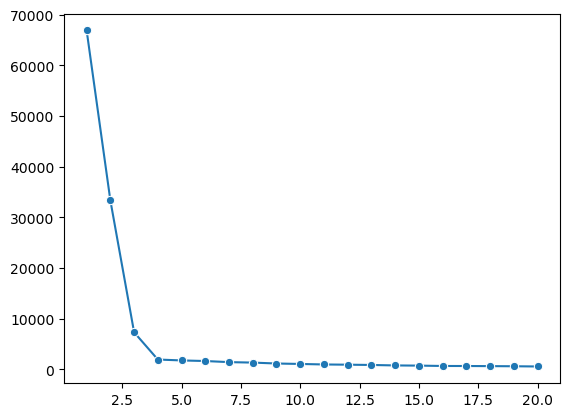

In [14]:
sns.lineplot(x =range(1,21) , y=wcss , marker = 'o')

In [15]:
# Auto matic way to use Elbow 

# Kneed Module
!pip install Kneed

In [17]:
from kneed import KneeLocator

Knee = KneeLocator(
    range(1, 21),
    wcss,
    curve="convex",
    direction="decreasing"
)

print("optimal K:", Knee.elbow)

optimal K: 4


In [27]:
# Silhouette Score 

from sklearn.metrics import silhouette_score

ss=[]
for K in range(2,21):
    kmeans = KMeans(n_clusters =K)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X,labels)
    ss.append(score)

<Axes: >

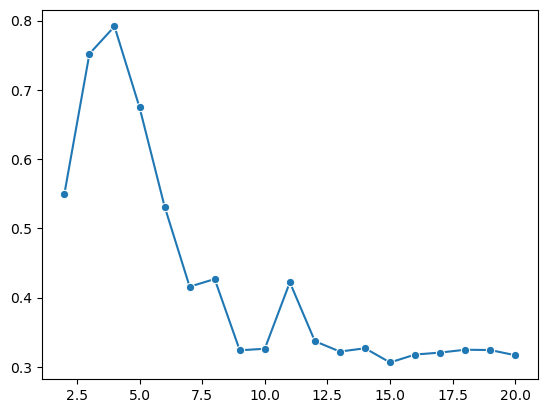

In [29]:
# plot K nd ss

sns.lineplot(x =range(2,21) ,y =ss  ,marker = 'o')